# **Estandarización iLOD - Test 250 pgmL Sciex 7500+**




## **Análisis de repetibilidad instrumental**

# **1. Introducción**

# **2. Metodología de trabajo**

SAS Institute defines data mining as the process of Sampling, Exploring, Modifying, Modeling, and Assessing (SEMMA) large amounts of data to uncover previously unknown patterns which can be used as a business advantage. The data mining process is applicable across a variety of industries and provides methodologies for such diverse business problems as fraud detection, householding, customer retention and attrition, database marketing, market segmentation, risk analysis, affinity analysis, customer satisfaction, bankruptcy prediction, and portfolio analysis.

Enterprise Miner software is an integrated product that provides an end-to-end business solution for data mining.
A graphical user interface (GUI) provides a user-friendly front end to the SEMMA data mining process:

*   Sample the data by creating one or more data tables. The samples should be large enough to contain the significant information, yet small enough to process.

*   Explore the data by searching for anticipated relationships, unanticipated trends, and anomalies in order to gain understanding and ideas.

*   Modify the data by creating, selecting, and transforming the variables to focus the model selection process.

*   Model the data by using the analytical tools to search for a combination of the data that reliably predicts a desired outcome.
Assess the data by evaluating the usefulness and reliability of the findings from the data mining process.

# **0. Cargue de librerías**

En esta sección del Script se cargan todas las librerías necesarias para el análisis de los datos

In [1]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [2]:
# En este chunk dejamos totas las librerías que vamos a necesitar. Recomiendo siempre reutilizar este al comenzar un nuevo trabajo.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Numpy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Seaborn version:", sns.__version__)

Numpy version: 2.0.2
Pandas version: 2.2.2
Seaborn version: 0.13.2


## **2.1 Sampling**

Se realiza lectura de los datos y se toma una fracción de los mismos para análisis.

### **2.1.1 Lectura de datos**

In [3]:
#Cargar el archivo
# Asegúrate de ajustar el separador ('\t' o ',' dependiendo del formato real)
df = pd.read_csv("iLOD-Results-Gaussian1-250pgml.txt", sep="\t")

In [4]:
#Vista general de la base de datos
print(df.head())

   Index    Sample Name Sample Type          Component Name Component Type  \
0   2341  Nivel-250pgmL    Standard  3 HYDROXY CARBOFURAN-1    Quantifiers   
1   2342  Nivel-250pgmL    Standard  3 HYDROXY CARBOFURAN-2     Qualifiers   
2   2343  Nivel-250pgmL    Standard         ABAMECTIN B1a-1    Quantifiers   
3   2344  Nivel-250pgmL    Standard         ABAMECTIN B1a-2     Qualifiers   
4   2345  Nivel-250pgmL    Standard              ACEPHATE-1    Quantifiers   

   Component Group Name  Actual Concentration  Expected RT           Area  \
0  3 HYDROXY CARBOFURAN                   250         3.34  262671.513445   
1  3 HYDROXY CARBOFURAN                     0         3.34  111390.301133   
2         ABAMECTIN B1a                     0        11.81     655.000040   
3         ABAMECTIN B1a                     0        11.81     253.580137   
4              ACEPHATE                     0         2.02  416740.919937   

   Retention Time  Retention Time Delta (min)  Signal / Noise  Used 

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2340 entries, 0 to 2339
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Index                       2340 non-null   int64  
 1   Sample Name                 2340 non-null   object 
 2   Sample Type                 2340 non-null   object 
 3   Component Name              2340 non-null   object 
 4   Component Type              2340 non-null   object 
 5   Component Group Name        2340 non-null   object 
 6   Actual Concentration        2340 non-null   int64  
 7   Expected RT                 2340 non-null   float64
 8   Area                        2326 non-null   float64
 9   Retention Time              2326 non-null   float64
 10  Retention Time Delta (min)  2326 non-null   float64
 11  Signal / Noise              2326 non-null   float64
 12  Used                        2340 non-null   bool   
 13  Calculated Concentration    2326 

### **2.1.2 Muestreo de los datos**

In [6]:
# Seleccionar las columnas relevantes
cols = ["Component Group Name", "Component Type", "Area", "Retention Time"]
df_Sampled = df[cols]

In [7]:
# Asegurarse de que los datos numéricos estén correctamente convertidos
df_Sampled["Area"] = pd.to_numeric(df_Sampled["Area"], errors="coerce")
df_Sampled["Retention Time"] = pd.to_numeric(df_Sampled["Retention Time"], errors="coerce")

/tmp/ipython-input-3035842048.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Sampled["Area"] = pd.to_numeric(df_Sampled["Area"], errors="coerce")
/tmp/ipython-input-3035842048.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Sampled["Retention Time"] = pd.to_numeric(df_Sampled["Retention Time"], errors="coerce")


In [8]:
print(df_Sampled.head())

   Component Group Name Component Type           Area  Retention Time
0  3 HYDROXY CARBOFURAN    Quantifiers  262671.513445        3.333549
1  3 HYDROXY CARBOFURAN     Qualifiers  111390.301133        3.332794
2         ABAMECTIN B1a    Quantifiers     655.000040       12.061983
3         ABAMECTIN B1a     Qualifiers     253.580137       12.095368
4              ACEPHATE    Quantifiers  416740.919937        2.013501


In [9]:
print(df_Sampled.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2340 entries, 0 to 2339
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Component Group Name  2340 non-null   object 
 1   Component Type        2340 non-null   object 
 2   Area                  2326 non-null   float64
 3   Retention Time        2326 non-null   float64
dtypes: float64(2), object(2)
memory usage: 73.3+ KB
None


## **2.2 Exploración de datos**

### **2.2.1 Limpieza de base de datos**

En esta sección se revisa la base de datos para la busqueda de datos faltantes, duplicados y errores de transcripción.

**Busqueda de datos faltantes**




In [10]:
#Este código suma el total de valores faltantes por columna y los presenta
df_Sampled.isna().sum()

,0
Component Group Name,0
Component Type,0
Area,14
Retention Time,14


**Eliminación de datos faltantes**



In [11]:
df_Sampled.dropna(inplace=True)
df_Sampled.isna().sum()

/tmp/ipython-input-3147249471.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Sampled.dropna(inplace=True)


,0
Component Group Name,0
Component Type,0
Area,0
Retention Time,0


**Busqueda de duplicados**

In [12]:
#Aquí se realiza la suma total de los datos duplicados
df_Sampled.duplicated().sum()

np.int64(0)

In [13]:
df_Sampled.drop_duplicates(inplace=True)
df_Sampled.duplicated().sum()

/tmp/ipython-input-1519474588.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Sampled.drop_duplicates(inplace=True)


np.int64(0)

## **2.3 Modificación de datos**



### **2.3.1 Busqueda de datos anómalos**

In [14]:
# -----------------------
# 🔟 Detección de datos anómalos (outliers)
# -----------------------

def detectar_outliers(grupo, columna):
    q1 = grupo[columna].quantile(0.25)
    q3 = grupo[columna].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    return grupo[(grupo[columna] < lim_inf) | (grupo[columna] > lim_sup)]

# Detectar outliers en ambas variables
outliers_area = df_Sampled.groupby("Component Group Name", group_keys=False).apply(detectar_outliers, "Area")
outliers_rt = df_Sampled.groupby("Component Group Name", group_keys=False).apply(detectar_outliers, "Retention Time")

# Etiquetar el tipo de outlier
outliers_area["Tipo"] = "Área"
outliers_rt["Tipo"] = "Tiempo de Retención"

# Unir ambos
outliers_total = pd.concat([outliers_area, outliers_rt]).reset_index(drop=True)

# Resumen de cantidad de outliers por grupo
resumen_outliers = (
    outliers_total.groupby(["Component Group Name", "Tipo"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
resumen_outliers["Total Outliers"] = resumen_outliers.sum(axis=1, numeric_only=True)

print(resumen_outliers)

/tmp/ipython-input-4105352263.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers_area = df_Sampled.groupby("Component Group Name", group_keys=False).apply(detectar_outliers, "Area")


Tipo Component Group Name  Tiempo de Retención  Área  Total Outliers
0           ABAMECTIN B1a                    2     0               2
1                ALDICARB                    1     0               1
2            AZIMSULFURON                    2     0               2
3          AZINPHOS ETHYL                    1     0               1
4         AZINPHOS METHYL                    2     0               2
..                    ...                  ...   ...             ...
130      TOLCLOFOS METHYL                    3     0               3
131           TRIADIMEFON                    2     0               2
132          TRIASULFURON                    1     0               1
133       TRIFLOXYSTROBIN                    2     0               2
134           TRIFLUMURON                    4     0               4

[135 rows x 4 columns]


/tmp/ipython-input-4105352263.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers_rt = df_Sampled.groupby("Component Group Name", group_keys=False).apply(detectar_outliers, "Retention Time")


In [15]:
# Guardar los resultados
outliers_total.to_excel("Datos_outliers_detalle.xlsx", index=False)

# Save the first sheet to the Excel file, creating the file if it doesn't exist
with pd.ExcelWriter("Resumen_estadistico_por_componente.xlsx", mode="w", engine="openpyxl") as writer:
    resumen_outliers.to_excel(writer, sheet_name="Outliers por Grupo", index=False)

# Append the second sheet to the existing Excel file
with pd.ExcelWriter("Resumen_estadistico_por_componente.xlsx", mode="a", engine="openpyxl") as writer:
    outliers_total.to_excel(writer, sheet_name="Outlier Details", index=False)

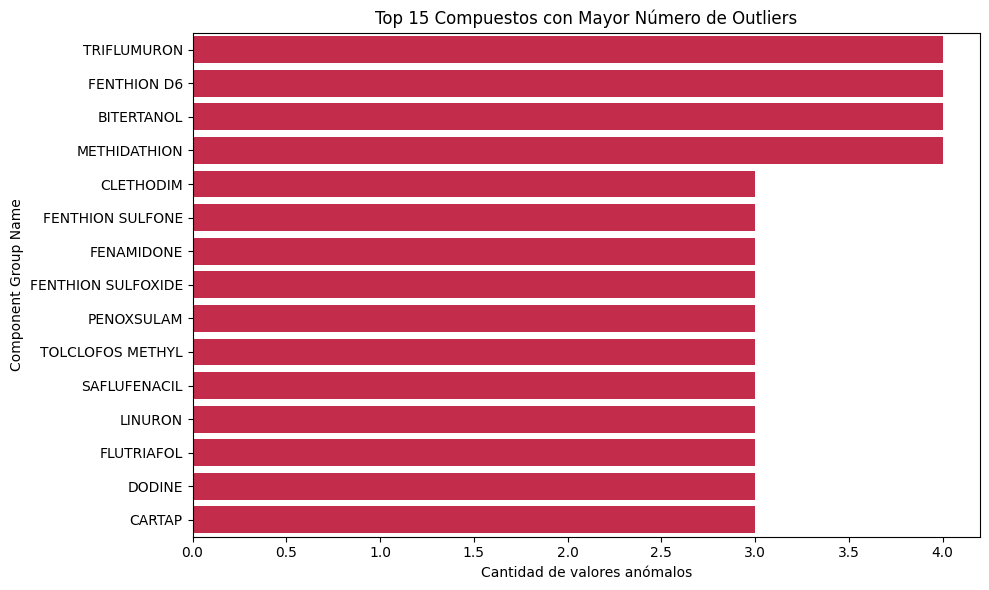

In [16]:
#Visualización de grupos con más outliers

top_outliers = resumen_outliers.sort_values("Total Outliers", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=top_outliers, x="Total Outliers", y="Component Group Name", color="crimson")
plt.title("Top 15 Compuestos con Mayor Número de Outliers")
plt.xlabel("Cantidad de valores anómalos")
plt.ylabel("Component Group Name")
plt.tight_layout()


### **2.3.2 Eliminación de datos anómalos**

In [17]:
# Eliminación de outliers por grupo (método IQR)

def filtrar_outliers(grupo, columna):
    q1 = grupo[columna].quantile(0.25)
    q3 = grupo[columna].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    return grupo[(grupo[columna] >= lim_inf) & (grupo[columna] <= lim_sup)]

# Filtrar datos válidos en ambas columnas
df_filtered = (
    df_Sampled.groupby("Component Group Name", group_keys=False)
      .apply(filtrar_outliers, "Area")
      .groupby("Component Group Name", group_keys=False)
      .apply(filtrar_outliers, "Retention Time")
)

# Verificar cantidad de datos eliminados
n_original = len(df)
n_filtrado = len(df_filtered)
print(f"✅ Datos filtrados por IQR completado.")
print(f"   Registros originales: {n_original}")
print(f"   Registros después de limpiar: {n_filtrado}")
print(f"   Registros eliminados: {n_original - n_filtrado}")

# Guardar base de datos limpia
print(df_filtered.head())
print(df_filtered.info())


/tmp/ipython-input-3477491267.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(filtrar_outliers, "Area")


✅ Datos filtrados por IQR completado.
   Registros originales: 2340
   Registros después de limpiar: 2069
   Registros eliminados: 271
     Component Group Name Component Type           Area  Retention Time
0    3 HYDROXY CARBOFURAN    Quantifiers  262671.513445        3.333549
1    3 HYDROXY CARBOFURAN     Qualifiers  111390.301133        3.332794
468  3 HYDROXY CARBOFURAN    Quantifiers  217204.558242        3.338958
469  3 HYDROXY CARBOFURAN     Qualifiers  118535.449291        3.340246
936  3 HYDROXY CARBOFURAN    Quantifiers  232805.789274        3.341349
<class 'pandas.core.frame.DataFrame'>
Index: 2069 entries, 0 to 2339
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Component Group Name  2069 non-null   object 
 1   Component Type        2069 non-null   object 
 2   Area                  2069 non-null   float64
 3   Retention Time        2069 non-null   float64
dtypes: float64(2), object

/tmp/ipython-input-3477491267.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(filtrar_outliers, "Retention Time")


## **2.4 Exploración**

### **2.4.1 Análisis gráfico exploratorio**

Text(0.5, 0, 'Área')

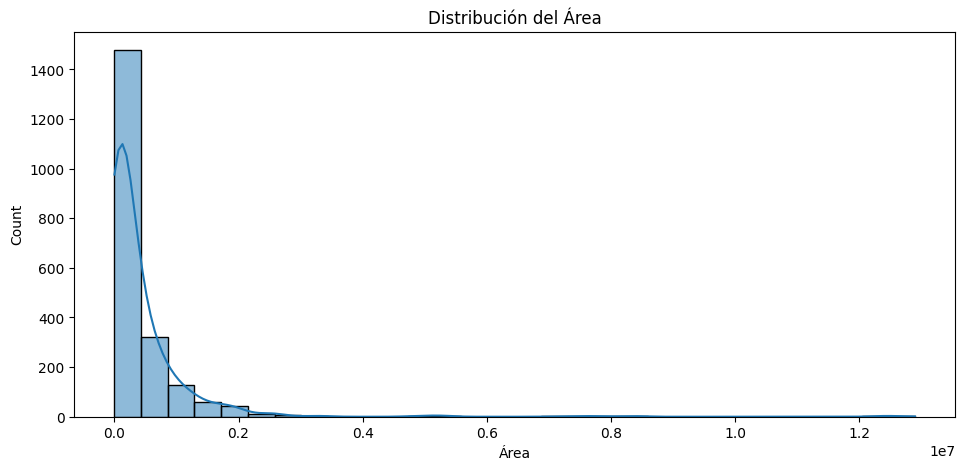

In [18]:
plt.figure(figsize=(25,5))
plt.subplot(1,2,1)
sns.histplot(df_filtered["Area"], kde=True, bins=30)
plt.title("Distribución del Área")
plt.xlabel("Área")

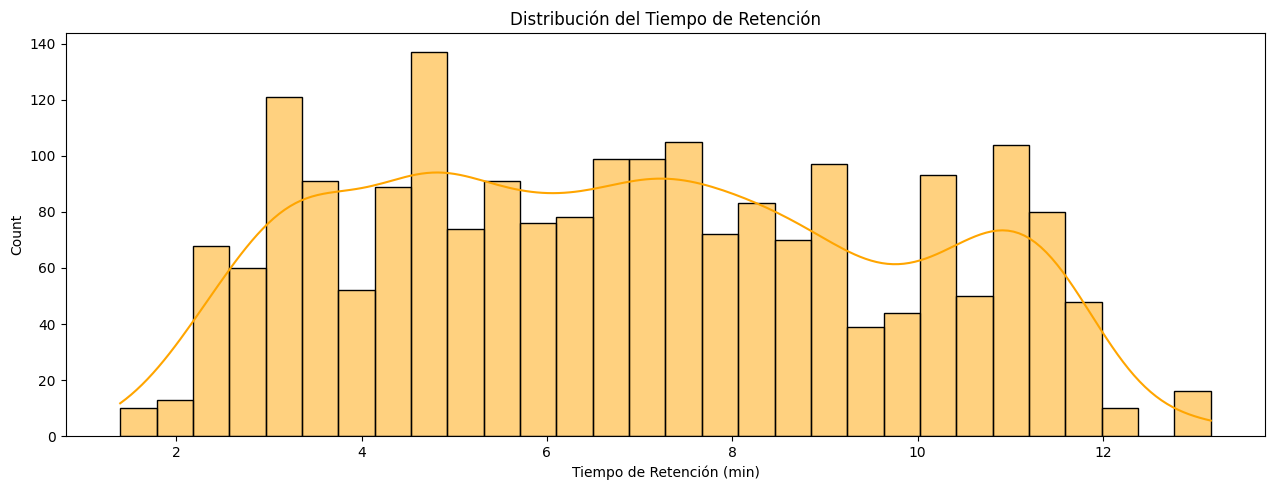

In [19]:
plt.figure(figsize=(25,5))
plt.subplot(1,2,2)
sns.histplot(df_filtered["Retention Time"], kde=True, bins=30, color="orange")
plt.title("Distribución del Tiempo de Retención")
plt.xlabel("Tiempo de Retención (min)")
plt.tight_layout()

### **2.2.4 Estadísticos de resumen**

In [20]:
# 3️⃣ Asegurarse de que los datos numéricos estén correctamente convertidos
df_filtered["Area"] = pd.to_numeric(df_filtered["Area"], errors="coerce")
df_filtered["Retention Time"] = pd.to_numeric(df_filtered["Retention Time"], errors="coerce")

In [21]:
print(df_filtered.head())

     Component Group Name Component Type           Area  Retention Time
0    3 HYDROXY CARBOFURAN    Quantifiers  262671.513445        3.333549
1    3 HYDROXY CARBOFURAN     Qualifiers  111390.301133        3.332794
468  3 HYDROXY CARBOFURAN    Quantifiers  217204.558242        3.338958
469  3 HYDROXY CARBOFURAN     Qualifiers  118535.449291        3.340246
936  3 HYDROXY CARBOFURAN    Quantifiers  232805.789274        3.341349


In [22]:
# -----------------------
# 4️⃣ Agrupar por "Component Type" y "Component Group Name" y calcular estadísticas descriptivas
# -----------------------

stats = df.groupby(["Component Type", "Component Group Name"]).agg({
    "Area": ["count", "mean", "std", "min", "max"],
    "Retention Time": ["mean", "std", "min", "max"]
})

# -----------------------
# 5️⃣ Calcular el %CV (coeficiente de variación)
# -----------------------
stats[("Area", "%CV")] = (stats[("Area", "std")] / stats[("Area", "mean")]) * 100
stats[("Retention Time", "%CV")] = (stats[("Retention Time", "std")] / stats[("Retention Time", "mean")]) * 100

# -----------------------
# 6️⃣ Reorganizar columnas para mejor visualización
# -----------------------
stats = stats[
    [
        ("Area", "count"), ("Area", "mean"), ("Area", "std"), ("Area", "%CV"),
        ("Retention Time", "mean"), ("Retention Time", "std"), ("Retention Time", "%CV")
    ]
]

# -----------------------
# 7️⃣ Exportar resultados a Excel
# -----------------------
# Aplanar nombres de columnas antes de exportar (evita errores con MultiIndex)
stats.columns = ['_'.join(col).strip() for col in stats.columns.values]
stats = stats.reset_index()

# Guardar en Excel
stats.to_excel("Resumen_estadistico_por_tipo_y_componente.xlsx", index=False)

print("✅ Análisis completado con éxito.")
print("📄 Archivo generado: 'Resumen_estadistico_por_tipo_y_componente.xlsx'")

✅ Análisis completado con éxito.
📄 Archivo generado: 'Resumen_estadistico_por_tipo_y_componente.xlsx'


In [23]:
print(stats.head())

  Component Type  Component Group Name  Area_count      Area_mean  \
0     Qualifiers  3 HYDROXY CARBOFURAN           5  118972.739860   
1     Qualifiers         ABAMECTIN B1a           5    2010.531436   
2     Qualifiers              ACEPHATE           5   28264.416897   
3     Qualifiers           ACEQUINOCYL           5    6163.017687   
4     Qualifiers           ACETAMIPRID           5   17059.108377   

       Area_std   Area_%CV  Retention Time_mean  Retention Time_std  \
0  13590.510410  11.423214             3.337056            0.006501   
1   1061.590209  52.801473            11.880798            0.120122   
2   3047.428617  10.781856             2.018337            0.005909   
3   1798.208152  29.177397            12.947039            0.006989   
4   2702.040437  15.839283             3.354362            0.005260   

   Retention Time_%CV  
0            0.194801  
1            1.011059  
2            0.292746  
3            0.053981  
4            0.156817  


## **2.5 Modelamiento**

### **2.5.1 Graficos de resumen %CV**

In [24]:
print(stats.head())

  Component Type  Component Group Name  Area_count      Area_mean  \
0     Qualifiers  3 HYDROXY CARBOFURAN           5  118972.739860   
1     Qualifiers         ABAMECTIN B1a           5    2010.531436   
2     Qualifiers              ACEPHATE           5   28264.416897   
3     Qualifiers           ACEQUINOCYL           5    6163.017687   
4     Qualifiers           ACETAMIPRID           5   17059.108377   

       Area_std   Area_%CV  Retention Time_mean  Retention Time_std  \
0  13590.510410  11.423214             3.337056            0.006501   
1   1061.590209  52.801473            11.880798            0.120122   
2   3047.428617  10.781856             2.018337            0.005909   
3   1798.208152  29.177397            12.947039            0.006989   
4   2702.040437  15.839283             3.354362            0.005260   

   Retention Time_%CV  
0            0.194801  
1            1.011059  
2            0.292746  
3            0.053981  
4            0.156817  


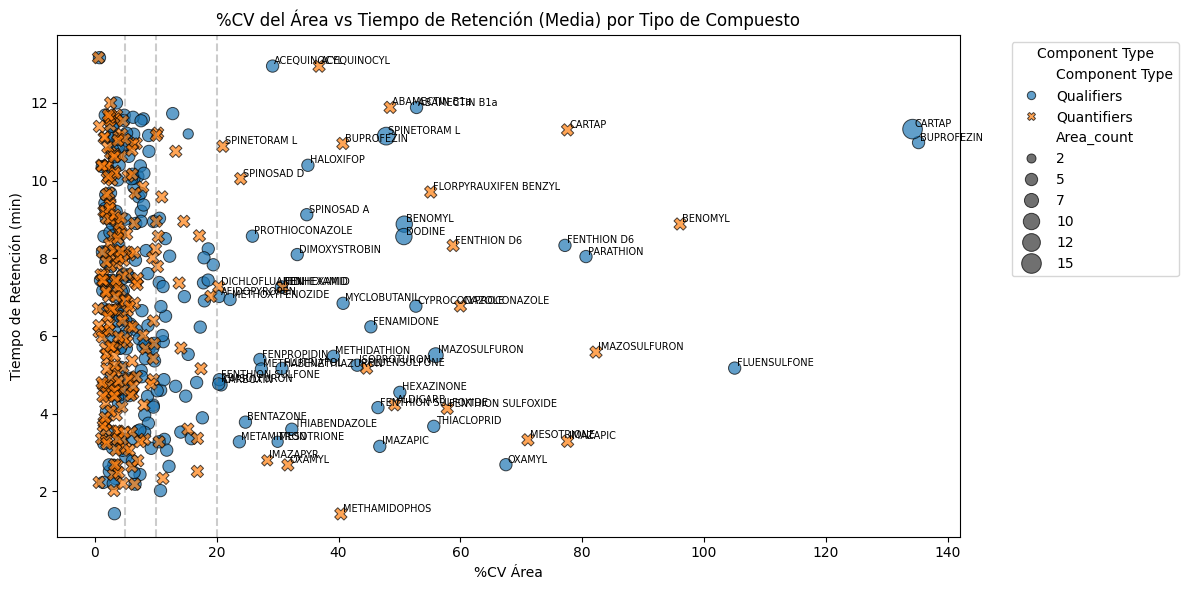

In [25]:
# -----------------------
# 🎯 Scatter plot %CV Área vs Tiempo de Retención (media), separado por Compound Type (en color)
# -----------------------

# Aplanar nombres de columnas si aún no se ha hecho
if isinstance(stats.columns, pd.MultiIndex):
    stats.columns = ['_'.join(col).strip() for col in stats.columns.values]
stats_reset = stats.reset_index()

# Crear categorías de variabilidad
def clasificar_cv(valor):
    if valor > 20:
        return "Alta (>20%)"
    elif valor > 10:
        return "Media (10-20%)"
    elif valor > 5:
        return "Baja (5-10%)"
    else:
        return "Muy baja (<5%)"

# Clasificar según %CV del área
stats_reset["Categoria_Area"] = stats_reset["Area_%CV"].apply(clasificar_cv)

# Crear gráfico combinado
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=stats_reset,
    x="Area_%CV",
    y="Retention Time_mean",
    hue="Component Type",           # ← separa por tipo
    style="Component Type",         # ← diferente marcador
    size="Area_count",
    sizes=(30, 200),
    alpha=0.7,
    edgecolor="black"
)

# Etiquetar solo los compuestos con alta variabilidad
for _, row in stats_reset.iterrows():
    if row["Area_%CV"] > 20:
        plt.text(row["Area_%CV"] + 0.3, row["Retention Time_mean"] + 0.05,
                 row["Component Group Name"], fontsize=7)

# Líneas de referencia
plt.axvline(5, color="gray", linestyle="--", alpha=0.4)
plt.axvline(10, color="gray", linestyle="--", alpha=0.4)
plt.axvline(20, color="gray", linestyle="--", alpha=0.4)

plt.title("%CV del Área vs Tiempo de Retención (Media) por Tipo de Compuesto")
plt.xlabel("%CV Área")
plt.ylabel("Tiempo de Retención (min)")
plt.legend(title="Component Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


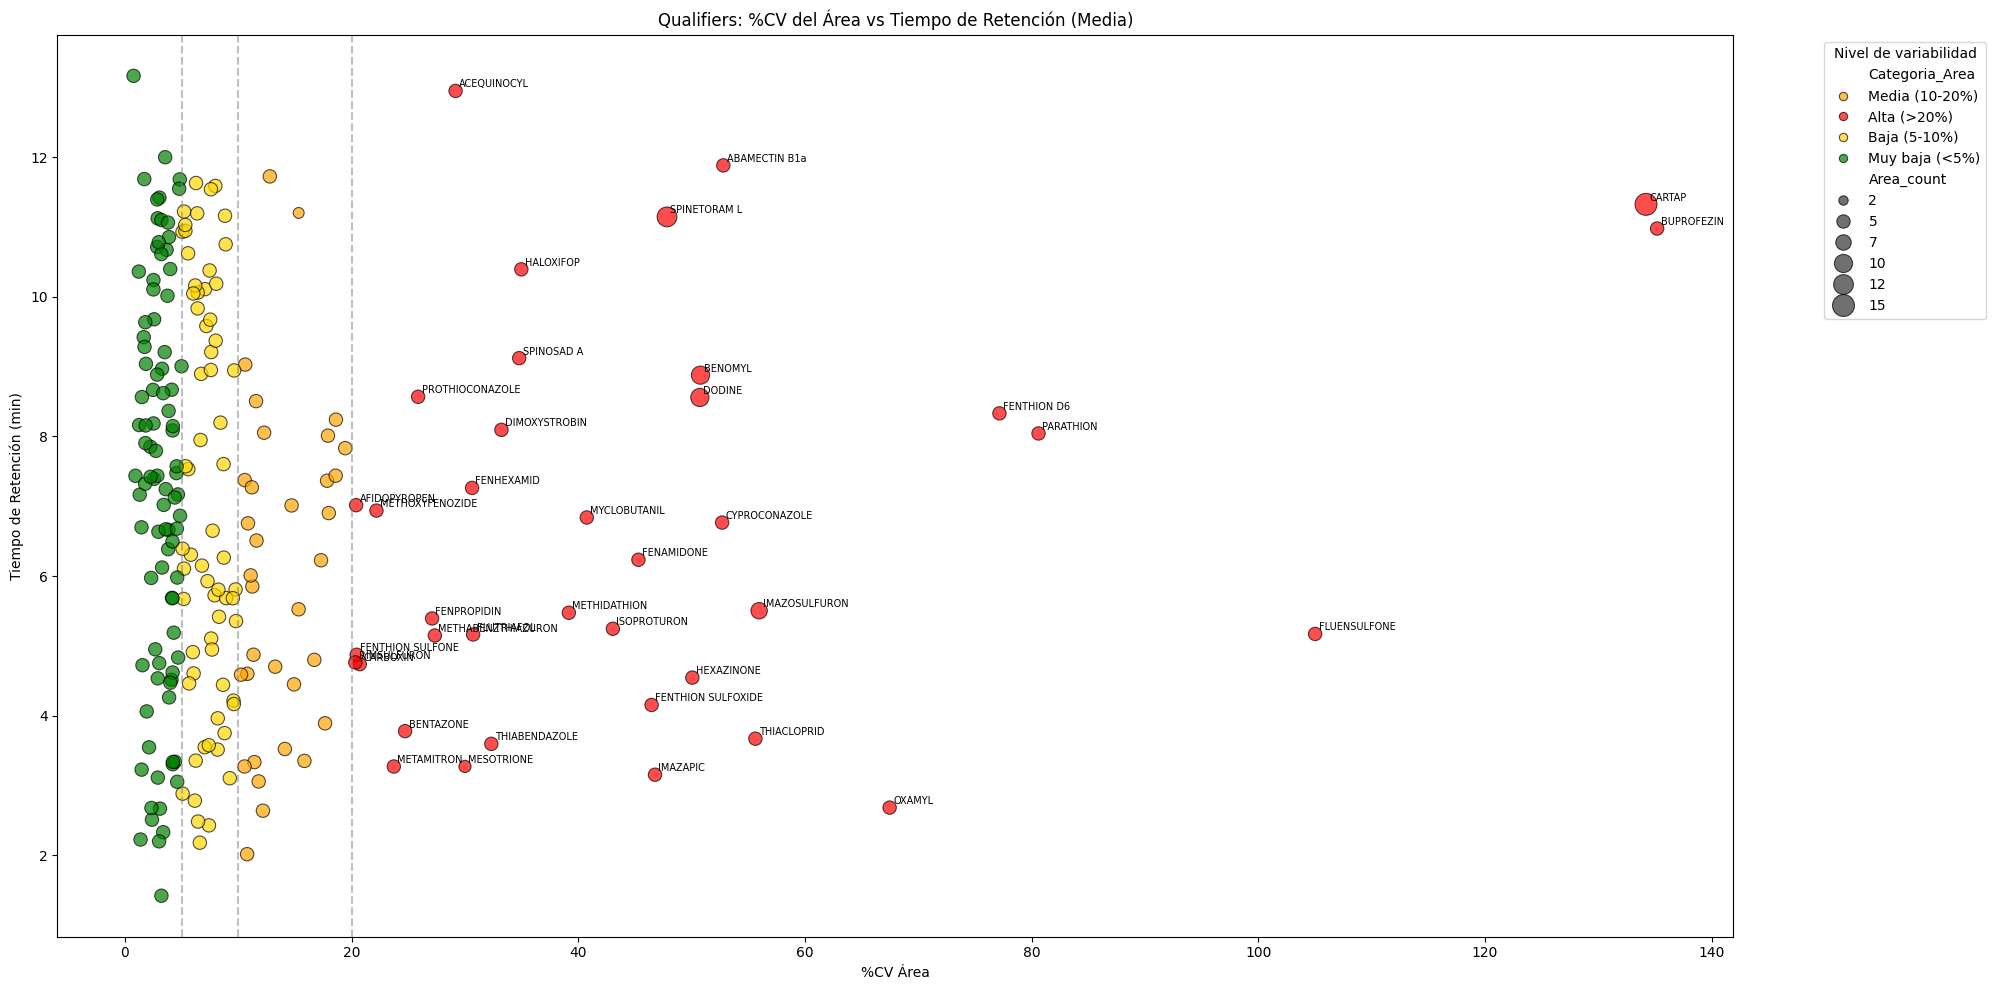

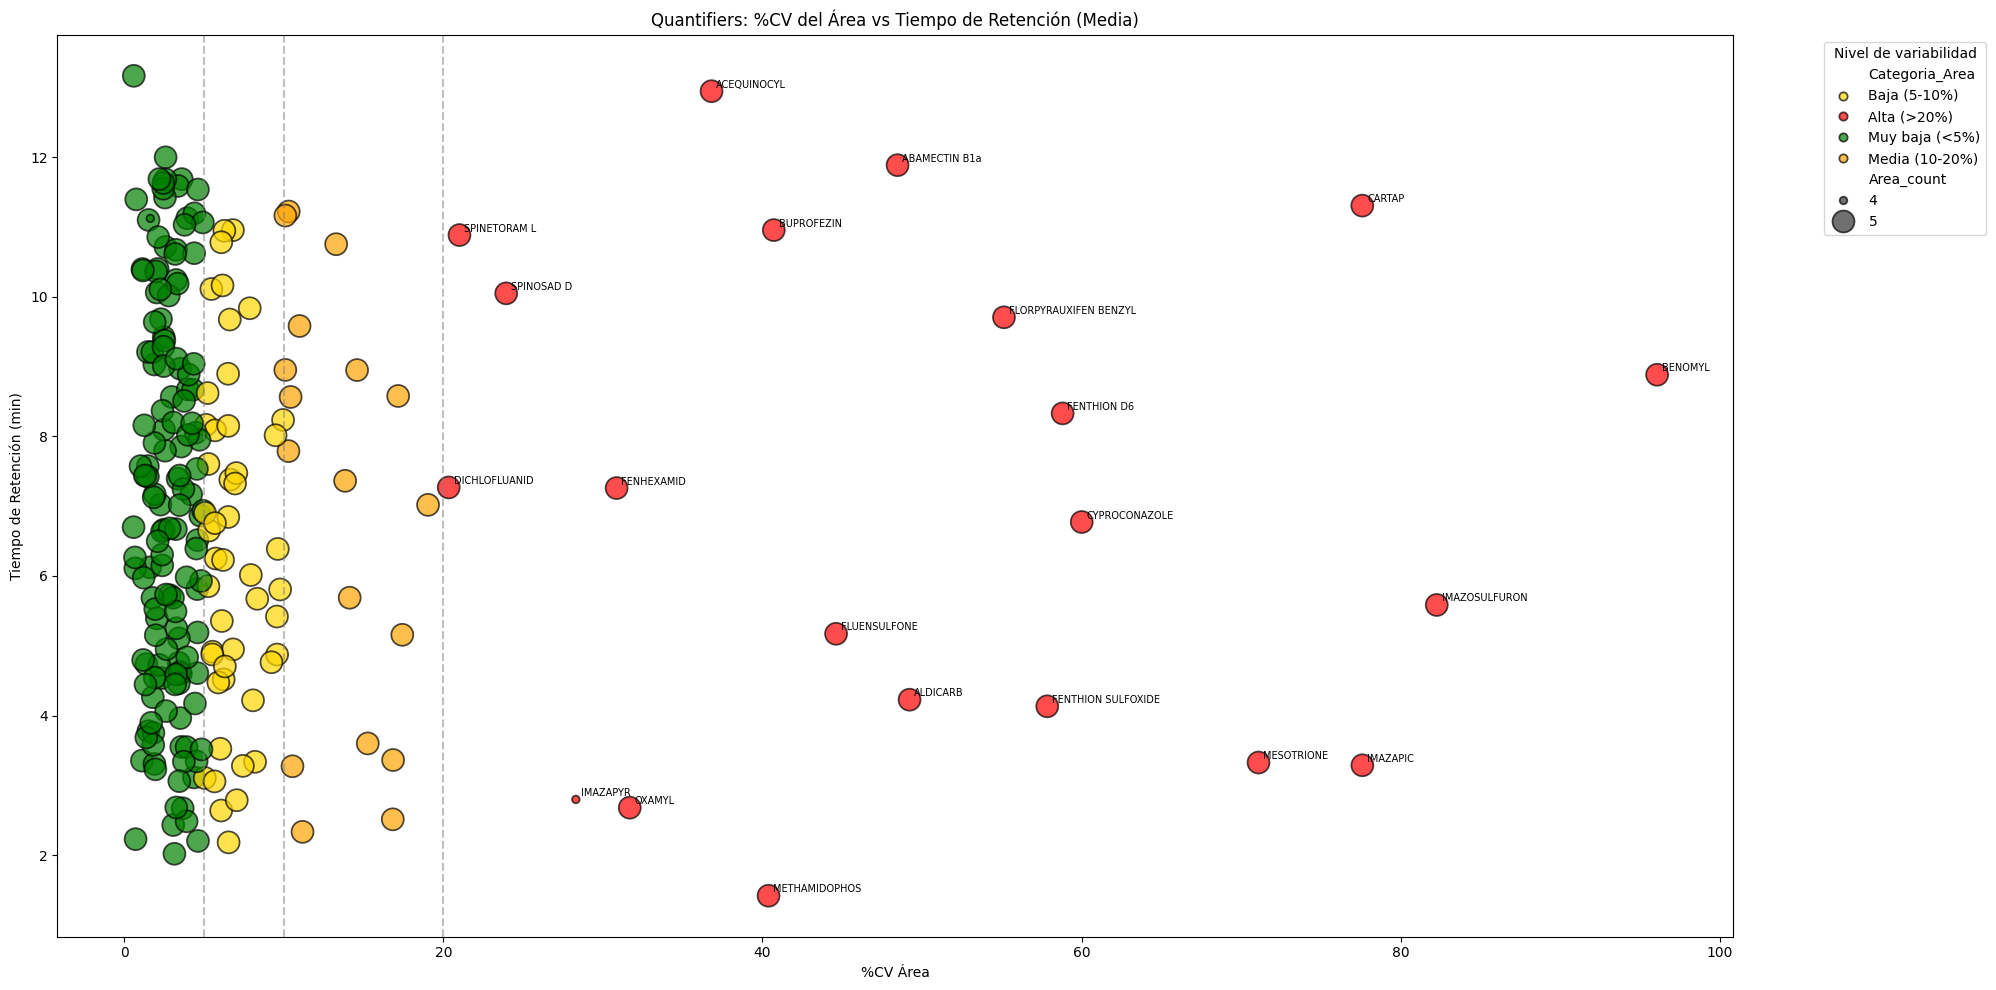

In [26]:
# -----------------------
# 📊 Scatter plots separados por Compound Type
# -----------------------

compound_types = stats_reset["Component Type"].unique()

for ctype in compound_types:
    subset = stats_reset[stats_reset["Component Type"] == ctype]

    plt.figure(figsize=(20,10))
    sns.scatterplot(
        data=subset,
        x="Area_%CV",
        y="Retention Time_mean",
        hue="Categoria_Area",
        palette={
            "Alta (>20%)": "red",
            "Media (10-20%)": "orange",
            "Baja (5-10%)": "gold",
            "Muy baja (<5%)": "green"
        },
        size="Area_count",
        sizes=(30, 250),
        alpha=0.7,
        edgecolor="black"
    )

    # Etiquetar los de alta variabilidad
    for _, row in subset.iterrows():
        if row["Area_%CV"] > 20:
            plt.text(row["Area_%CV"] + 0.3, row["Retention Time_mean"] + 0.05,
                     row["Component Group Name"], fontsize=7)

    plt.axvline(5, color="gray", linestyle="--", alpha=0.5)
    plt.axvline(10, color="gray", linestyle="--", alpha=0.5)
    plt.axvline(20, color="gray", linestyle="--", alpha=0.5)

    plt.title(f"{ctype}: %CV del Área vs Tiempo de Retención (Media)")
    plt.xlabel("%CV Área")
    plt.ylabel("Tiempo de Retención (min)")
    plt.legend(title="Nivel de variabilidad", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

In [27]:
print(stats.head())

  Component Type  Component Group Name  Area_count      Area_mean  \
0     Qualifiers  3 HYDROXY CARBOFURAN           5  118972.739860   
1     Qualifiers         ABAMECTIN B1a           5    2010.531436   
2     Qualifiers              ACEPHATE           5   28264.416897   
3     Qualifiers           ACEQUINOCYL           5    6163.017687   
4     Qualifiers           ACETAMIPRID           5   17059.108377   

       Area_std   Area_%CV  Retention Time_mean  Retention Time_std  \
0  13590.510410  11.423214             3.337056            0.006501   
1   1061.590209  52.801473            11.880798            0.120122   
2   3047.428617  10.781856             2.018337            0.005909   
3   1798.208152  29.177397            12.947039            0.006989   
4   2702.040437  15.839283             3.354362            0.005260   

   Retention Time_%CV  
0            0.194801  
1            1.011059  
2            0.292746  
3            0.053981  
4            0.156817  


In [28]:
# -----------------------
# 📊 Resumen detallado por Component Group Name y Compound Type
# -----------------------

# Seleccionar solo las columnas relevantes
cols_resumen = [
    "Component Type", "Component Group Name",
    "Area_count", "Area_mean", "Area_std", "Area_%CV",
    "Retention_Time_mean", "Retention_Time_std", "Retention_Time_%CV"
]

# Verificar que todas las columnas existan
cols_resumen = [c for c in cols_resumen if c in stats_reset.columns]

df_resumen = stats_reset[cols_resumen].copy()

# Redondear valores numéricos
df_resumen = df_resumen.round(3)

# Ordenar por nombre del componente y tipo
df_resumen = df_resumen.sort_values(by=["Component Group Name", "Component Type"])

# Mostrar parte del resumen en consola
print("\n📘 Resumen por Componente y Tipo:")
print(df_resumen.head(10))

# Guardar en Excel
with pd.ExcelWriter("Resumen_estadistico_por_tipo_y_componente.xlsx",
                    mode="a", engine="openpyxl", if_sheet_exists="overlay") as writer:
    df_resumen.to_excel(writer, sheet_name="Resumen_Componente_Tipo", index=False)

print("✅ Hoja 'Resumen_Componente_Tipo' añadida al archivo 'Resumen_estadistico_por_tipo_y_componente.xlsx'")



📘 Resumen por Componente y Tipo:
    Component Type  Component Group Name  Area_count   Area_mean   Area_std  \
0       Qualifiers  3 HYDROXY CARBOFURAN           5  118972.740  13590.510   
230    Quantifiers  3 HYDROXY CARBOFURAN           5  245043.071  20106.550   
1       Qualifiers         ABAMECTIN B1a           5    2010.531   1061.590   
231    Quantifiers         ABAMECTIN B1a           5    3166.295   1534.607   
2       Qualifiers              ACEPHATE           5   28264.417   3047.429   
232    Quantifiers              ACEPHATE           5  429043.802  13517.574   
3       Qualifiers           ACEQUINOCYL           5    6163.018   1798.208   
233    Quantifiers           ACEQUINOCYL           5   25163.212   9262.790   
4       Qualifiers           ACETAMIPRID           5   17059.108   2702.040   
234    Quantifiers           ACETAMIPRID           5  527732.088   5878.445   

     Area_%CV  
0      11.423  
230     8.205  
1      52.801  
231    48.467  
2      10.782  


In [29]:
print(df_resumen.head())

    Component Type  Component Group Name  Area_count   Area_mean   Area_std  \
0       Qualifiers  3 HYDROXY CARBOFURAN           5  118972.740  13590.510   
230    Quantifiers  3 HYDROXY CARBOFURAN           5  245043.071  20106.550   
1       Qualifiers         ABAMECTIN B1a           5    2010.531   1061.590   
231    Quantifiers         ABAMECTIN B1a           5    3166.295   1534.607   
2       Qualifiers              ACEPHATE           5   28264.417   3047.429   

     Area_%CV  
0      11.423  
230     8.205  
1      52.801  
231    48.467  
2      10.782  


In [30]:
# -----------------------
# 📊 Comparativo Quantifier vs Qualifier por Componente (versión robusta)
# -----------------------

# Detectar las columnas relevantes según palabras clave (por si hay diferencias en nombres)
cols_pivot = [c for c in df_resumen.columns if any(x in c for x in ["Area", "Retention", "Compound", "Component"])]

df_temp = df_resumen[cols_pivot].copy()

# Pivotear la tabla
tabla_comp = df_temp.pivot_table(
    index="Component Group Name",
    columns="Component Type",
    values=[c for c in df_temp.columns if c not in ["Component Type", "Component Group Name"]]
)

# Aplanar nombres de columnas
tabla_comp.columns = ['_'.join(col).strip().replace(' ', '_') for col in tabla_comp.columns.values]
tabla_comp = tabla_comp.reset_index()

print("📋 Columnas creadas tras pivot:")
print(tabla_comp.columns.tolist())

# Intentar localizar las columnas clave de forma automática
def encontrar_columna(pattern):
    posibles = [c for c in tabla_comp.columns if pattern in c]
    return posibles[0] if posibles else None

col_area_q = encontrar_columna("Area_%CV_Quantifiers")
col_area_ql = encontrar_columna("Area_%CV_Qualifiers")
col_rt_q = encontrar_columna("Retention") and encontrar_columna("%CV_Quantifiers")
col_rt_ql = encontrar_columna("Retention") and encontrar_columna("%CV_Qualifiers")

# Calcular diferencias si existen ambas columnas
if col_area_q and col_area_ql:
    tabla_comp["Dif_%CV_Area"] = tabla_comp[col_area_ql] - tabla_comp[col_area_q]
    tabla_comp["AbsDif_%CV_Area"] = tabla_comp["Dif_%CV_Area"].abs()
else:
    print("⚠️ No se encontraron ambas columnas de %CV de Área para Quantifiers y Qualifiers.")

if "Retention_Time_%CV_Quantifiers" in tabla_comp.columns and "Retention_Time_%CV_Qualifiers" in tabla_comp.columns:
    tabla_comp["Dif_%CV_Retencion"] = (
        tabla_comp["Retention_Time_%CV_Qualifiers"] - tabla_comp["Retention_Time_%CV_Quantifiers"]
    )
    tabla_comp["AbsDif_%CV_Retencion"] = tabla_comp["Dif_%CV_Retencion"].abs()
else:
    print("⚠️ No se encontraron ambas columnas de %CV de Retención.")

# Ordenar por diferencia absoluta de %CV de área
tabla_comp = tabla_comp.sort_values(by="AbsDif_%CV_Area", ascending=False, na_position='last')

# Redondear valores
tabla_comp = tabla_comp.round(3)

# Mostrar resumen
print("\n📗 Comparativo Quantifier vs Qualifier por componente:")
print(tabla_comp.head(10))

# Guardar en Excel
with pd.ExcelWriter("Resumen_estadistico_por_tipo_y_componente.xlsx",
                    mode="a", engine="openpyxl", if_sheet_exists="overlay") as writer:
    tabla_comp.to_excel(writer, sheet_name="Comparativo_Q_vs_Qf", index=False)

print("✅ Hoja 'Comparativo_Q_vs_Qf' añadida al archivo 'Resumen_estadistico_por_tipo_y_componente.xlsx'")


📋 Columnas creadas tras pivot:
['Component Group Name', 'Area_%CV_Qualifiers', 'Area_%CV_Quantifiers', 'Area_count_Qualifiers', 'Area_count_Quantifiers', 'Area_mean_Qualifiers', 'Area_mean_Quantifiers', 'Area_std_Qualifiers', 'Area_std_Quantifiers']
⚠️ No se encontraron ambas columnas de %CV de Retención.

📗 Comparativo Quantifier vs Qualifier por componente:
    Component Group Name  Area_%CV_Qualifiers  Area_%CV_Quantifiers  \
30            BUPROFEZIN              135.199                40.712   
170            PARATHION               80.615                 3.997   
103         FLUENSULFONE              105.021                44.615   
39                CARTAP              134.216                77.592   
219          THIACLOPRID               55.632                 1.389   
121           HEXAZINONE               50.069                 1.919   
18               BENOMYL               50.786                96.068   
142           MESOTRIONE               30.006                71.089   